# 20. Ver.5 K=2 を著者の手順で選ぶ

`VG1GC-66`、修正1の入力、π は一様。K=3 の数値はノート19のキャッシュを読むだけで、学習し直さない。

## 方針

K=2 は K=3 の解から状態を落とさず、公開実装の3段で単独に選ぶ。

1. **standard** — 全試行で乱数初期値を 25 点。遷移は Dirichlet(5, 1)、重みは一様 (−4, 4)。訓練対数尤度が最大の1つを、全 fold の初期値にする。著者スクリプトと同じで、この初期値の学習にはテスト試行も入る。σ>0 と κ<∞ の EM は訓練マスクだけを使う。
2. **partial** — 各 fold でその標準解から温スタートし、σ を小さい方から上げる。σ の指数は 1 刻みで、`10^{−3, −2, −1, 0, 1, 2, 3}` の 7 点。論文の 0.5 刻みは使わない。
3. **dynamic** — test 対数尤度が最大の σ に固定する。κ は `2×10^{n}`（n = −1,…,5、指数 1 刻み）の 7 点を大きい方から温スタートする。末尾の κ=∞ は partial を評価するだけで、EM しない。
4. **選ぶ規則** — σ は 5 fold の test 対数尤度の平均が最大の点。κ はノート19と同じ退化チェック（有限・非吸収・時計でない・全日が同じ順でない）を全 fold で通した点のうち、test 対数尤度が最大の点。

遷移の事前は standard / partial が `[10, 1]`、dynamic は無し。dynamic に渡す前に大域遷移行列の行を正規化する。


## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())


cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
DYN_REPO = Path('external') / 'dynamic_glmhmm'
if not (DYN_REPO / 'code' / 'dynamic_glmhmm.py').exists():
    DYN_REPO.parent.mkdir(parents=True, exist_ok=True)
    os.system(f'git clone --depth 1 https://github.com/lenca56/dynamic_glmhmm {DYN_REPO}')
if str((DYN_REPO / 'code').resolve()) not in sys.path:
    sys.path.insert(0, str((DYN_REPO / 'code').resolve()))

import dynamic_glmhmm
from analysis_utils import split_data
print('dynamic_glmhmm:', dynamic_glmhmm.__file__)


dynamic_glmhmm: /mnt/c/Users/dmasu/braidyn-bc/external/dynamic_glmhmm/code/dynamic_glmhmm.py


In [3]:
import time, io as _io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})
from matplotlib import font_manager
for _fp in [Path('/mnt/c/Windows/Fonts/YuGothM.ttc'), Path('/mnt/c/Windows/Fonts/meiryo.ttc'),
            Path('C:/Windows/Fonts/YuGothM.ttc'), Path('C:/Windows/Fonts/meiryo.ttc')]:
    if _fp.exists():
        font_manager.fontManager.addfont(str(_fp))
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(_fp)).get_name()
        break
print('font:', plt.rcParams['font.family'])

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT
ALPHA_REW = v4.ALPHA_REW
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
K, C = 2, 2
N_INITS = 25
P_THRESHOLD = 0.80
BURN = 20
FOLDS, BLOCKS, CV_SEED = 5, 10, 1
PAR_MAXITER, PAR_TOL = 200, 1e-3
PRIOR_DIR_P = [10, 1]
# 指数 1 刻み。論文の 0.5 刻みは使わない。
SIGMA_LIST = [10.0 ** e for e in range(-3, 4)]
ALPHA_LIST = [2.0 * (10.0 ** n) for n in range(-1, 6)]
POS_MEAN_LO, POS_MEAN_HI, POS_SD_MAX = 0.25, 0.75, 0.15
POS_MIN_N = 30
ABSORB_DIAG = 0.999
STATE_COLORS = ['#4c72b0', '#dd8452']

CACHE_DIR = Path('data') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TRIALS = CACHE_DIR / f'ver5_trials_{MOUSE_ID}.pkl'
NB19_CACHE = CACHE_DIR / 'ver5_note19.pkl'
NB20_CACHE = CACHE_DIR / 'ver5_note20.pkl'

if CACHE_TRIALS.exists():
    trials_all = pd.read_pickle(CACHE_TRIALS)
    print('キャッシュから読み込み:', CACHE_TRIALS)
else:
    trials_all = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)['trials']
    trials_all.to_pickle(CACHE_TRIALS)

NB19 = pd.read_pickle(NB19_CACHE)
if 'partial_folds' not in NB19 or len(NB19['partial_folds']) < FOLDS:
    raise RuntimeError('ノート19の partial_folds が揃っていない。先にノート19を実行する。')
NB20 = pd.read_pickle(NB20_CACHE) if NB20_CACHE.exists() else {}
NB20.setdefault('std_inits', {})
NB20.setdefault('partial', {})
NB20.setdefault('dyn', {})
NB20.setdefault('degen', {})
print('sigma:', SIGMA_LIST)
print('kappa:', ALPHA_LIST)
print('note20 keys:', sorted(NB20))


def save_cache():
    pd.to_pickle(NB20, NB20_CACHE)


@contextlib.contextmanager
def quiet():
    buf = _io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield


def as_global_P(P):
    A = np.array(P[0], dtype=float, copy=True)
    A /= A.sum(axis=1, keepdims=True)
    return A


def new_model():
    return dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)


def eval_ll(P, pi, W, present):
    present = np.asarray(present).astype(int)
    with quiet():
        _, ll, _ = new_model().evaluate(X, Y, SESS, present, P, pi, W)
    return float(ll)


def last_ll(ll):
    ll = np.asarray(ll, dtype=float)
    ll = ll[ll != 0]
    return float(ll[-1]) if ll.size else float('nan'), int(ll.size)


環境: ローカル (WSL)


DATA_CSV_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


font: ['Yu Gothic']
キャッシュから読み込み: data/cache/ver5_trials_VG1GC-66.pkl


sigma: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
kappa: [0.2, 2.0, 20.0, 200.0, 2000.0, 20000.0, 200000.0]
note20 keys: ['degen', 'dyn', 'final', 'folds', 'partial', 'std_inits']


## 1. 入力

ノート19と同じ修正1。履歴と報酬の指数移動平均は、全日プールの定常値から始める。fold 分割は `N` と `sessInd` だけで決まるのでノート19と同一になる。


In [4]:
def build_sequence(trials_all, h0=0.0, r0=0.0):
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = (g[g['trial_type'].isin(SOUND_TYPES)]
             .sort_values('t_start').reset_index(drop=True).copy())
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        h[0], r[0] = h0, r0
        for k in range(1, n):
            h[k] = a[k - 1] + ALPHA_ACT * h[k - 1]
            r[k] = rw[k - 1] + ALPHA_REW * r[k - 1]
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = 1 - a
        g['k'] = np.arange(n)
        out.append(g)
    tr = pd.concat(out, ignore_index=True)
    for c in ['x_hist', 'x_rew']:
        tr[c + '_z'] = (tr[c] - tr[c].mean()) / tr[c].std(ddof=0)
    return tr


INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']
tr_reset = build_sequence(trials_all)
H0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_hist'].mean())
R0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_rew'].mean())
tr = build_sequence(trials_all, H0, R0)

days = list(dict.fromkeys(tr['task_day'].tolist()))
X = tr[INPUT_COLS].to_numpy(dtype=float)
Y = tr['yA'].to_numpy().astype(int)
SESS = [0] + list(np.cumsum([int((tr['task_day'] == d).sum()) for d in days]))
N, D = X.shape
DAYS = days
DAY_LABELS = [str(d).replace('task-day', 'd') for d in DAYS]
PRESENT_ALL = np.ones(N, dtype=int)

presentTrain, presentTest = split_data(N, SESS, folds=FOLDS, blocks=BLOCKS, random_state=CV_SEED)
presentTrain = [np.asarray(p).astype(int) for p in presentTrain]
presentTest = [np.asarray(p).astype(int) for p in presentTest]
print(f'N={N}  D={D}  sessions={len(SESS)-1}  K={K}')
print('day別試行数:', [SESS[i+1] - SESS[i] for i in range(len(SESS)-1)])
print('foldごとのtest試行数:', [int(pt.sum()) for pt in presentTest])


N=2359  D=3  sessions=14  K=2
day別試行数: [np.int64(76), np.int64(156), np.int64(103), np.int64(183), np.int64(318), np.int64(157), np.int64(153), np.int64(72), np.int64(155), np.int64(233), np.int64(233), np.int64(126), np.int64(231), np.int64(163)]
foldごとのtest試行数: [548, 510, 479, 402, 420]


## 2. standard を 25 初期値

全試行で学習し、訓練対数尤度が最大の1つを残す。`sigma` は全成分 1（standard では重みをセッション間で動かさない）。


In [5]:
sigma_std = np.ones((K, D))
for i in range(N_INITS):
    key = str(i)
    if key in NB20['std_inits']:
        rec = NB20['std_inits'][key]
        print(f'init {i:02d}  cache  ll={rec["ll"]:.2f}  iter={rec["n_iter"]}')
        continue
    t0 = time.time()
    np.random.seed(i)
    model = new_model()
    initP, initpi, initW = model.generate_param(
        SESS,
        transitionDistribution=['dirichlet', (5, 1)],
        weightDistribution=['uniform', (-4, 4)],
        model_type='standard',
    )
    with quiet():
        p, pi, w, ll = model.fit(
            X, Y, PRESENT_ALL, initP, initpi, initW,
            sigma=sigma_std, alpha=0, sessInd=SESS,
            maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='standard',
            L2penaltyW=0, priorDirP=PRIOR_DIR_P, fit_init_states=False,
        )
    ll_hat, n_iter = last_ll(ll)
    NB20['std_inits'][key] = dict(p=p, pi=pi, w=w, ll=ll_hat, n_iter=n_iter)
    save_cache()
    print(f'init {i:02d}  ll={ll_hat:.2f}  iter={n_iter}  {time.time()-t0:.0f}s')

best_init = max(NB20['std_inits'], key=lambda k: NB20['std_inits'][k]['ll'])
BEST_STD = NB20['std_inits'][best_init]
print(f'最良 init={best_init}  train ll={BEST_STD["ll"]:.2f}')


init 00  cache  ll=-992.37  iter=166
init 01  cache  ll=-992.37  iter=106
init 02  cache  ll=-992.37  iter=93
init 03  cache  ll=-1000.82  iter=159
init 04  cache  ll=-1011.15  iter=93
init 05  cache  ll=-1000.82  iter=169
init 06  cache  ll=-992.37  iter=37
init 07  cache  ll=-992.37  iter=124
init 08  cache  ll=-992.37  iter=46
init 09  cache  ll=-992.37  iter=77
init 10  cache  ll=-992.37  iter=156
init 11  cache  ll=-1001.28  iter=51
init 12  cache  ll=-1000.67  iter=50
init 13  cache  ll=-1000.83  iter=98
init 14  cache  ll=-1001.28  iter=39
init 15  cache  ll=-1000.88  iter=200
init 16  cache  ll=-992.37  iter=93
init 17  cache  ll=-992.37  iter=151
init 18  cache  ll=-1001.28  iter=77
init 19  cache  ll=-992.37  iter=154
init 20  cache  ll=-992.37  iter=49
init 21  cache  ll=-992.37  iter=72
init 22  cache  ll=-1004.94  iter=87
init 23  cache  ll=-992.37  iter=60
init 24  cache  ll=-992.37  iter=73
最良 init=1  train ll=-992.37


## 3. partial の σ 掃引

スロット 0 は標準解をその fold のテストで評価するだけで、学習し直さない。続く 7 点は直前の解から温スタートする。


In [6]:
for f in range(FOLDS):
    chain = NB20['partial'].setdefault(str(f), {})
    if '0' not in chain:
        t0 = time.time()
        ll = eval_ll(BEST_STD['p'], BEST_STD['pi'], BEST_STD['w'], presentTest[f])
        chain['0'] = dict(
            p=BEST_STD['p'], pi=BEST_STD['pi'], w=BEST_STD['w'],
            ll_test=ll, sigma=0.0,
        )
        save_cache()
        print(f'fold {f}  standard  test ll={ll:.4f}  {time.time()-t0:.0f}s')
    for i, sig in enumerate(SIGMA_LIST):
        key = str(i + 1)
        if key in chain:
            print(f'fold {f}  sigma={sig:g}  cache  test ll={chain[key]["ll_test"]:.4f}')
            continue
        prev = chain[str(i)]
        t0 = time.time()
        with quiet():
            p, pi, w, ll = new_model().fit(
                X, Y, presentTrain[f], prev['p'], prev['pi'], prev['w'],
                sigma=np.full((K, D), float(sig)), alpha=0, sessInd=SESS,
                maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='partial',
                L2penaltyW=0, priorDirP=PRIOR_DIR_P, fit_init_states=False,
            )
        ll_hat, n_iter = last_ll(ll)
        ll_test = eval_ll(p, pi, w, presentTest[f])
        chain[key] = dict(p=p, pi=pi, w=w, ll_train=ll_hat, ll_test=ll_test,
                          n_iter=n_iter, sigma=float(sig))
        save_cache()
        print(f'fold {f}  sigma={sig:g}  test ll={ll_test:.4f}  iter={n_iter}  {time.time()-t0:.0f}s')


fold 0  sigma=0.001  test ll=-0.4153  iter=11  3s


fold 0  sigma=0.01  test ll=-0.4154  iter=110  24s


fold 0  sigma=0.1  test ll=-0.4126  iter=125  35s


fold 0  sigma=1  test ll=-0.4155  iter=124  69s


fold 0  sigma=10  test ll=-0.4470  iter=50  32s


...

fold 4  sigma=0.1  test ll=-0.3973  iter=129  35s


fold 4  sigma=1  test ll=-0.3976  iter=20  12s


fold 4  sigma=10  test ll=-0.4035  iter=58  31s


fold 4  sigma=100  test ll=-0.4048  iter=11  6s


fold 4  sigma=1000  test ll=-0.4053  iter=26  14s


## 4. σ を test 対数尤度で選ぶ

dynamic に渡す σ は partial の 7 点のうち平均が最大のもの。標準解（表の σ=0）は参照で、dynamic の σ にはしない。


In [7]:
rows = []
for i, sig in enumerate([0.0] + SIGMA_LIST):
    lls = [NB20['partial'][str(f)][str(i)]['ll_test'] for f in range(FOLDS)]
    rows.append({
        'sigma': sig,
        'test_ll': float(np.mean(lls)),
        'se': float(np.std(lls, ddof=0) / np.sqrt(FOLDS)),
    })
sigma_df = pd.DataFrame(rows)
best_sigma_row = int(sigma_df.loc[sigma_df['sigma'] > 0, 'test_ll'].idxmax())
BEST_SIGMA = float(sigma_df.loc[best_sigma_row, 'sigma'])
BEST_SIGMA_SLOT = best_sigma_row
NB20['best_sigma'] = BEST_SIGMA
save_cache()
print(sigma_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'選んだ sigma={BEST_SIGMA:g}  (partial スロット {BEST_SIGMA_SLOT})')


    sigma  test_ll     se
   0.0000  -0.4208 0.0055
   0.0010  -0.4211 0.0055
   0.0100  -0.4211 0.0056
   0.1000  -0.4180 0.0055
   1.0000  -0.4203 0.0061
  10.0000  -0.4371 0.0084
 100.0000  -0.4580 0.0181
1000.0000  -0.4772 0.0287
選んだ sigma=0.1  (partial スロット 3)


## 5. dynamic の κ 掃引

選んだ σ の partial 解から始める。κ は大きい方から温スタートし、最後に κ=∞（partial の評価のみ）を置く。`alphaList` を降順に回すのは公開の `fit_eval_CV_dynamic_model` と同じ向き。


In [8]:
KAPPA_LABELS = [f'{a:g}' for a in ALPHA_LIST] + ['inf']

for f in range(FOLDS):
    slot = NB20['dyn'].setdefault(str(f), {})
    if slot.get('sigma') != BEST_SIGMA:
        slot.clear()
        slot['sigma'] = BEST_SIGMA
    partial = NB20['partial'][str(f)][str(BEST_SIGMA_SLOT)]
    A = as_global_P(partial['p'])
    if 'inf' not in slot:
        ll = eval_ll(partial['p'], partial['pi'], partial['w'], presentTest[f])
        slot['inf'] = dict(p=partial['p'], pi=partial['pi'], w=partial['w'],
                           ll_test=ll, kappa=float('inf'))
        save_cache()
        print(f'fold {f}  kappa=inf  test ll={ll:.4f}')
    prev_label = 'inf'
    for lab, alpha in zip(reversed(KAPPA_LABELS[:-1]), reversed(ALPHA_LIST)):
        if lab in slot:
            print(f'fold {f}  kappa={lab}  cache  test ll={slot[lab]["ll_test"]:.4f}')
            prev_label = lab
            continue
        prev = slot[prev_label]
        t0 = time.time()
        with quiet():
            p, pi, w, ll = new_model().fit(
                X, Y, presentTrain[f], prev['p'], prev['pi'], prev['w'],
                sigma=np.full((K, D), BEST_SIGMA), alpha=float(alpha), A=A, sessInd=SESS,
                maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='dynamic',
                L2penaltyW=0, priorDirP=None, fit_init_states=False,
            )
        ll_hat, n_iter = last_ll(ll)
        ll_test = eval_ll(p, pi, w, presentTest[f])
        slot[lab] = dict(p=p, pi=pi, w=w, ll_train=ll_hat, ll_test=ll_test,
                         n_iter=n_iter, kappa=float(alpha))
        save_cache()
        print(f'fold {f}  kappa={lab}  test ll={ll_test:.4f}  iter={n_iter}  {time.time()-t0:.0f}s')
        prev_label = lab


fold 0  kappa=inf  test ll=-0.4126


fold 0  kappa=200000  test ll=-0.4126  iter=11  3s


fold 0  kappa=20000  test ll=-0.4126  iter=11  3s


fold 0  kappa=2000  test ll=-0.4126  iter=11  3s


fold 0  kappa=200  test ll=-0.4126  iter=32  8s


...

fold 4  kappa=2000  test ll=-0.3971  iter=11  4s


fold 4  kappa=200  test ll=-0.3961  iter=11  4s


fold 4  kappa=20  test ll=-0.3945  iter=190  70s


fold 4  kappa=2  test ll=-0.3988  iter=176  75s


fold 4  kappa=0.2  test ll=-0.4004  iter=200  75s


## 6. 退化チェックと κ の選択

通過条件はノート19と同じ。有限であること、対角が 0.999 以上の日が無いこと、状態の day 内位置が端に寄って散らばらないこと、全日が同じ3分割の順にならないこと。全 fold で通った κ のうち test 対数尤度が最大の点を採る。


In [9]:
def decode_params(P, pi, W):
    with quiet():
        gamma = new_model().posterior_likelihood_of_each_state(
            P, pi, W, X, Y, PRESENT_ALL, SESS)
    return gamma, gamma.argmax(axis=1), gamma.max(axis=1)


def degeneracy_one(P, pi, W):
    finite = bool(np.isfinite(P).all() and np.isfinite(pi).all() and np.isfinite(W).all())
    absorb_days = []
    if finite:
        for s in range(len(DAYS)):
            M = P[SESS[s]]
            if np.isnan(M).any() or np.any(np.diag(M) >= ABSORB_DIAG):
                absorb_days.append(s)
    clock_states = []
    same_order = False
    pos_txt = []
    if finite and not np.isnan(P).any():
        gamma, z, pmax = decode_params(P, pi, W)
        for k in range(K):
            chunks = []
            for s in range(len(DAYS)):
                sl = slice(SESS[s], SESS[s + 1])
                rel = np.linspace(0, 1, SESS[s + 1] - SESS[s], endpoint=False)
                chunks.append(rel[z[sl] == k])
            v = np.concatenate(chunks) if chunks else np.array([])
            if v.size == 0:
                pos_txt.append('n=0')
                continue
            pos_txt.append(f'{v.mean():.2f}±{v.std():.2f}')
            if v.size >= POS_MIN_N and (v.mean() < POS_MEAN_LO or v.mean() > POS_MEAN_HI) and v.std() < POS_SD_MAX:
                clock_states.append(k)
        orders = []
        for s in range(len(DAYS)):
            zi = z[SESS[s]:SESS[s + 1]]
            n = len(zi)
            cuts = [0, n // 3, 2 * n // 3, n]
            thirds = []
            for a, b in zip(cuts[:-1], cuts[1:]):
                if b > a:
                    thirds.append(int(np.bincount(zi[a:b], minlength=K).argmax()))
            orders.append(tuple(thirds))
        same_order = len(set(orders)) == 1 and len(set(orders[0])) > 1
    ok = finite and not absorb_days and not clock_states and not same_order
    return dict(ok=ok, finite=finite, n_absorb_days=len(absorb_days),
                clock_states=clock_states, same_order=same_order, pos=' / '.join(pos_txt))


rows = []
for lab in KAPPA_LABELS:
    fold_ok = []
    lls = []
    for f in range(FOLDS):
        ck = f'{BEST_SIGMA:g}:{f}:{lab}'
        if ck not in NB20['degen']:
            packed = NB20['dyn'][str(f)][lab]
            NB20['degen'][ck] = degeneracy_one(packed['p'], packed['pi'], packed['w'])
            save_cache()
        d = NB20['degen'][ck]
        fold_ok.append(d['ok'])
        lls.append(NB20['dyn'][str(f)][lab]['ll_test'])
        rows.append({
            'kappa': lab, 'fold': f, 'pass': d['ok'], 'finite': d['finite'],
            'absorb_days': d['n_absorb_days'],
            'clock': ','.join(map(str, d['clock_states'])) or '-',
            'same_order': d['same_order'], 'pos': d['pos'], 'll_test': lls[-1],
        })
    print(f'kappa={lab:>8}  pass {sum(fold_ok)}/{FOLDS}  test ll={np.mean(lls):.4f}')

degen_df = pd.DataFrame(rows)
summary = (degen_df.groupby('kappa', sort=False)
           .agg(test_ll=('ll_test', 'mean'), se=('ll_test', lambda s: float(np.std(s, ddof=0) / np.sqrt(len(s)))),
                n_pass=('pass', 'sum'))
           .reset_index())
print(summary.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
eligible = summary[summary['n_pass'] == FOLDS]
if eligible.empty:
    chosen = summary.loc[summary['test_ll'].idxmax()]
    print('全 fold を通った kappa が無い。test 対数尤度最大を暫定にする。')
else:
    chosen = eligible.loc[eligible['test_ll'].idxmax()]
KAPPA_BEST = chosen['kappa']
NB20['kappa_best'] = KAPPA_BEST
save_cache()
print(f'選んだ kappa={KAPPA_BEST}  test ll={chosen["test_ll"]:.4f} ± {chosen["se"]:.4f}')


kappa=     0.2  pass 0/5  test ll=-0.4193


kappa=       2  pass 0/5  test ll=-0.4184


kappa=      20  pass 0/5  test ll=-0.4171


kappa=     200  pass 5/5  test ll=-0.4175


kappa=    2000  pass 5/5  test ll=-0.4179


kappa=   20000  pass 5/5  test ll=-0.4179


kappa=  200000  pass 5/5  test ll=-0.4179


kappa=     inf  pass 5/5  test ll=-0.4180
 kappa  test_ll     se  n_pass
   0.2  -0.4193 0.0053       0
     2  -0.4184 0.0053       0
    20  -0.4171 0.0058       0
   200  -0.4175 0.0055       5
  2000  -0.4179 0.0055       5
 20000  -0.4179 0.0055       5
200000  -0.4179 0.0055       5
   inf  -0.4180 0.0055       5


選んだ kappa=200  test ll=-0.4175 ± 0.0055


## 7. 全データで採択解を学習し、K=3 と比べる

採択した σ の partial を全試行で学習し、κ が有限ならそこから dynamic を1回だけ続ける。K=3 はノート19の partial（σ=1、κ=∞）の fold 別 test 対数尤度。


full partial  sigma=0.1  train ll=-977.38  iter=137  51s


full dynamic  kappa=200  train ll=-975.18  iter=29  12s


[K=2  sigma=0.1  kappa=200]
  1状態が90%以上のday: 11/14  (最頻状態占有率の中央値 1.000)
  day内の状態切り替え: 合計 3 回 / day中央値 0  / day別 [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0]
  state run長: 中央値 153 試行 / 最大 250
  p_max 平均 0.922 / P(z)>=0.8 残存率 0.868
    state 0: n=1658  pos 0.504 ± 0.282
    state 1: n= 701  pos 0.480 ± 0.303
  |W| の最大 1.81


findfont: Failed to find font weight normal, now using 500.


  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      75         0                0
 task-day3    156     125         0               26
 task-day4    103     103         0                0
 task-day5    183     171         0                0
 task-day6    318     241         0                0
 task-day7    157     157         0                0
 task-day8    153     122         0                0
 task-day9     72      72         0                0
task-day10    155     119         0                0
task-day11    233     233         0                0
task-day12    233     215         0                0
task-day13    126     107         0                0
task-day14    231     188         8              118
task-day15    163     119         0                0
balanced 使用可能試行: 144 / min_cell=0 の day 13/14
K=2 test ll -0.4175 ± 0.0055
K=3 test ll -0.4223 ± 0.0060  (ノート19 partial, sigma=1)
差 (K2-K3) 0.0047 ± 0.0019
fold差: ['+0.0104', '-0.0012', '+0.0085', '+0.0049

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


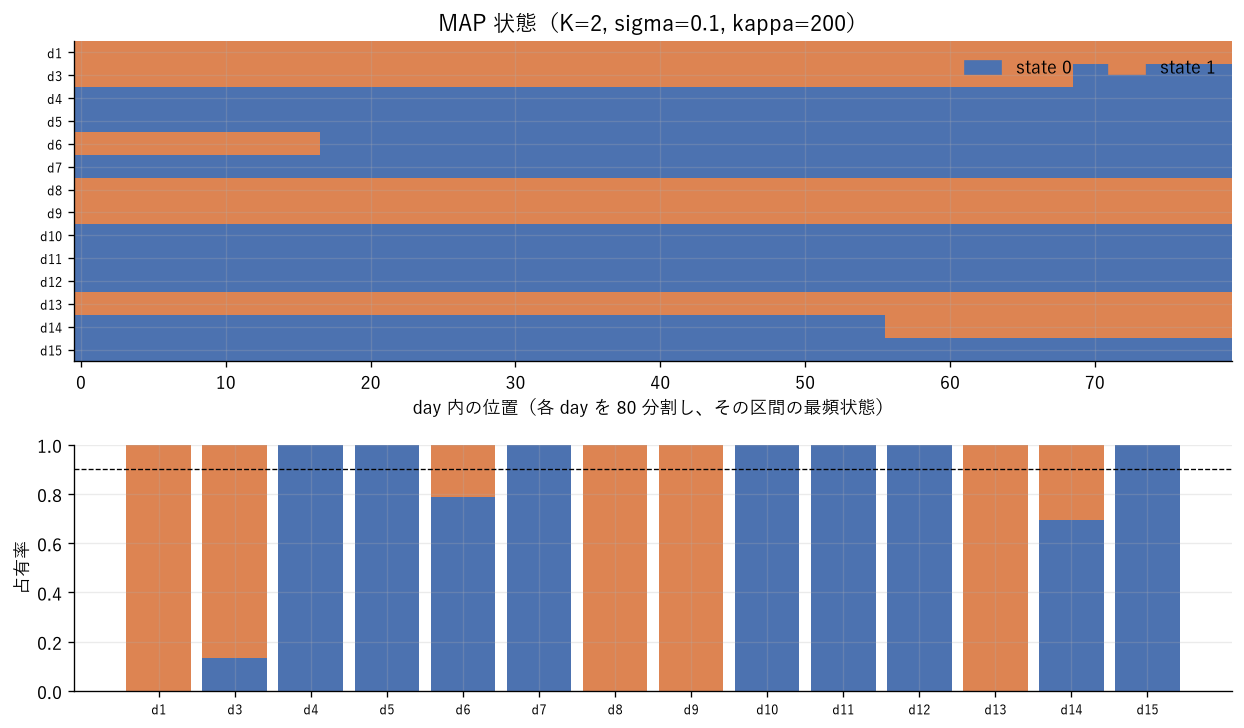

In [10]:
def state_summary(P, pi, W, label):
    gamma, z, pmax = decode_params(P, pi, W)
    occ = np.zeros((len(DAYS), K))
    switches, runs = [], []
    pos_by_state = [[] for _ in range(K)]
    for i in range(len(DAYS)):
        sl = slice(SESS[i], SESS[i + 1])
        zi = z[sl]
        for k in range(K):
            occ[i, k] = (zi == k).mean()
        switches.append(int((np.diff(zi) != 0).sum()))
        cut = np.flatnonzero(np.diff(zi) != 0) + 1
        runs += [len(s) for s in np.split(zi, cut)]
        rel = np.linspace(0, 1, len(zi), endpoint=False)
        for k in range(K):
            pos_by_state[k].append(rel[zi == k])
    dom = occ.max(axis=1)
    print(f'[{label}]')
    print(f'  1状態が90%以上のday: {int((dom >= 0.9).sum())}/{len(DAYS)}'
          f'  (最頻状態占有率の中央値 {np.median(dom):.3f})')
    print(f'  day内の状態切り替え: 合計 {sum(switches)} 回 / day中央値 {int(np.median(switches))}'
          f'  / day別 {switches}')
    print(f'  state run長: 中央値 {int(np.median(runs))} 試行 / 最大 {max(runs)}')
    print(f'  p_max 平均 {pmax.mean():.3f} / P(z)>={P_THRESHOLD} 残存率 {(pmax >= P_THRESHOLD).mean():.3f}')
    for k in range(K):
        v = np.concatenate(pos_by_state[k]) if pos_by_state[k] else np.array([])
        desc = f'{v.mean():.3f} ± {v.std():.3f}' if v.size else 'n/a'
        print(f'    state {k}: n={int((z == k).sum()):4d}  pos {desc}')
    print(f'  |W| の最大 {np.abs(W[:, :, :, 1]).max():.2f}')
    return dict(gamma=gamma, z=z, pmax=pmax, occ=occ, switches=np.array(switches), dom=dom)


def balancing_table(sm):
    t2 = tr.copy()
    t2['state'] = sm['z']
    t2['p_max'] = sm['pmax']
    kept = t2[t2['p_max'] >= P_THRESHOLD]
    rows = []
    for d in DAYS:
        g = kept[kept['task_day'] == d]
        ct = pd.crosstab(g['trial_type'], g['state'])
        ct = ct.reindex(index=SOUND_TYPES, columns=range(K), fill_value=0)
        rows.append({
            'task_day': d,
            'n_all': int((t2['task_day'] == d).sum()),
            'n_kept': len(g),
            'min_cell': int(ct.values.min()),
            'usable_balanced': int((ct.min(axis=1) * K).sum()),
        })
    return pd.DataFrame(rows)


final_key = f'{BEST_SIGMA:g}:{KAPPA_BEST}'
if NB20.get('final_sweep_key') != final_key:
    t0 = time.time()
    with quiet():
        p, pi, w, ll = new_model().fit(
            X, Y, PRESENT_ALL, BEST_STD['p'], BEST_STD['pi'], BEST_STD['w'],
            sigma=np.full((K, D), BEST_SIGMA), alpha=0, sessInd=SESS,
            maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='partial',
            L2penaltyW=0, priorDirP=PRIOR_DIR_P, fit_init_states=False,
        )
    ll_hat, n_iter = last_ll(ll)
    print(f'full partial  sigma={BEST_SIGMA:g}  train ll={ll_hat:.2f}  iter={n_iter}  {time.time()-t0:.0f}s')
    if KAPPA_BEST != 'inf':
        A = as_global_P(p)
        t0 = time.time()
        with quiet():
            p, pi, w, ll = new_model().fit(
                X, Y, PRESENT_ALL, p, pi, w,
                sigma=np.full((K, D), BEST_SIGMA), alpha=float(KAPPA_BEST), A=A, sessInd=SESS,
                maxIter=PAR_MAXITER, tol=PAR_TOL, model_type='dynamic',
                L2penaltyW=0, priorDirP=None, fit_init_states=False,
            )
        ll_hat, n_iter = last_ll(ll)
        print(f'full dynamic  kappa={KAPPA_BEST}  train ll={ll_hat:.2f}  iter={n_iter}  {time.time()-t0:.0f}s')
    NB20['final_sweep'] = dict(p=p, pi=pi, w=w, ll_train=ll_hat, n_iter=n_iter,
                               sigma=BEST_SIGMA, kappa=KAPPA_BEST)
    NB20['final_sweep_key'] = final_key
    save_cache()

final = NB20['final_sweep']
sm = state_summary(final['p'], final['pi'], final['w'],
                   f'K=2  sigma={BEST_SIGMA:g}  kappa={KAPPA_BEST}')
bal = balancing_table(sm)
print(bal.to_string(index=False))
print(f'balanced 使用可能試行: {int(bal["usable_balanced"].sum())} / '
      f'min_cell=0 の day {int((bal["min_cell"] == 0).sum())}/{len(bal)}')

k2 = [NB20['dyn'][str(f)][KAPPA_BEST]['ll_test'] for f in range(FOLDS)]
k3 = [NB19['partial_folds'][str(f)]['ll_test'] for f in range(FOLDS)]
delta = np.asarray(k2) - np.asarray(k3)
print(f'K=2 test ll {np.mean(k2):.4f} ± {np.std(k2, ddof=0)/np.sqrt(FOLDS):.4f}')
print(f'K=3 test ll {np.mean(k3):.4f} ± {np.std(k3, ddof=0)/np.sqrt(FOLDS):.4f}  (ノート19 partial, sigma=1)')
print(f'差 (K2-K3) {delta.mean():.4f} ± {np.std(delta, ddof=0)/np.sqrt(FOLDS):.4f}')
print('fold差:', [f'{d:+.4f}' for d in delta])

BINS = 80
raster = np.full((len(DAYS), BINS), np.nan)
for i in range(len(DAYS)):
    zi = sm['z'][SESS[i]:SESS[i + 1]]
    for b in range(BINS):
        a = int(b / BINS * len(zi))
        c = int((b + 1) / BINS * len(zi))
        chunk = zi[a:max(c, a + 1)]
        raster[i, b] = np.bincount(chunk, minlength=K).argmax()

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2),
                         gridspec_kw={'height_ratios': [1.3, 1]})
ax = axes[0]
cmap = plt.matplotlib.colors.ListedColormap(STATE_COLORS)
ax.imshow(raster, aspect='auto', cmap=cmap, vmin=-0.5, vmax=K - 0.5, interpolation='nearest')
ax.set_yticks(range(len(DAYS)))
ax.set_yticklabels(DAY_LABELS, fontsize=8)
ax.set_xlabel('day 内の位置（各 day を 80 分割し、その区間の最頻状態）')
ax.set_title(f'MAP 状態（K=2, sigma={BEST_SIGMA:g}, kappa={KAPPA_BEST}）')
handles = [plt.matplotlib.patches.Patch(color=STATE_COLORS[k], label=f'state {k}') for k in range(K)]
ax.legend(handles=handles, frameon=False, ncol=K, loc='upper right')
ax = axes[1]
bottom = np.zeros(len(DAYS))
for k in range(K):
    ax.bar(np.arange(len(DAYS)), sm['occ'][:, k], bottom=bottom, color=STATE_COLORS[k], width=0.85)
    bottom += sm['occ'][:, k]
ax.axhline(0.9, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(DAYS)))
ax.set_xticklabels(DAY_LABELS, fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel('占有率')
fig.tight_layout()
plt.show()
